# Demo of the Library Sandbox

KPIs ----------------------------------------
Number of kpis :  45
Number of kpis groups:  3
Number of living labs :  9
ID: lab_munich
Name: Munich
Number of KPIs: 42
Number of Measures: 14
----------------------------------------
ID: lab_geneva
Name: Geneva
Number of KPIs: 28
Number of Measures: 10
----------------------------------------
ID: lab_jerusalem
Name: Jerusalem
Number of KPIs: 29
Number of Measures: 13
----------------------------------------
ID: lab_athens_penteli
Name: Penteli
Number of KPIs: 34
Number of Measures: 8
----------------------------------------
ID: lab_rotterdam
Name: Rotterdam
Number of KPIs: 30
Number of Measures: 9
----------------------------------------
ID: lab_krakow
Name: Krakow
Number of KPIs: 31
Number of Measures: 9
----------------------------------------
ID: lab_fredrikstad
Name: Fredrikstad
Number of KPIs: 0
Number of Measures: 11
----------------------------------------
ID: lab_larnaca
Name: Larnaca
Number of KPIs: 25
Number of Measures: 4
-----

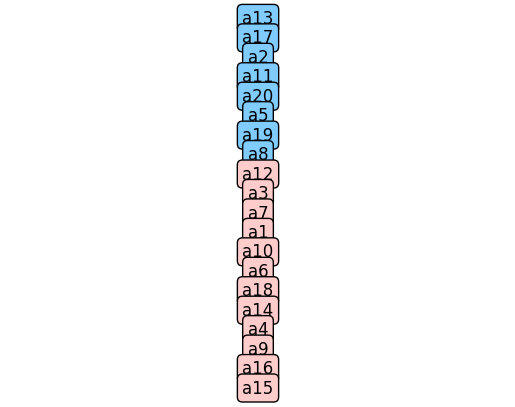

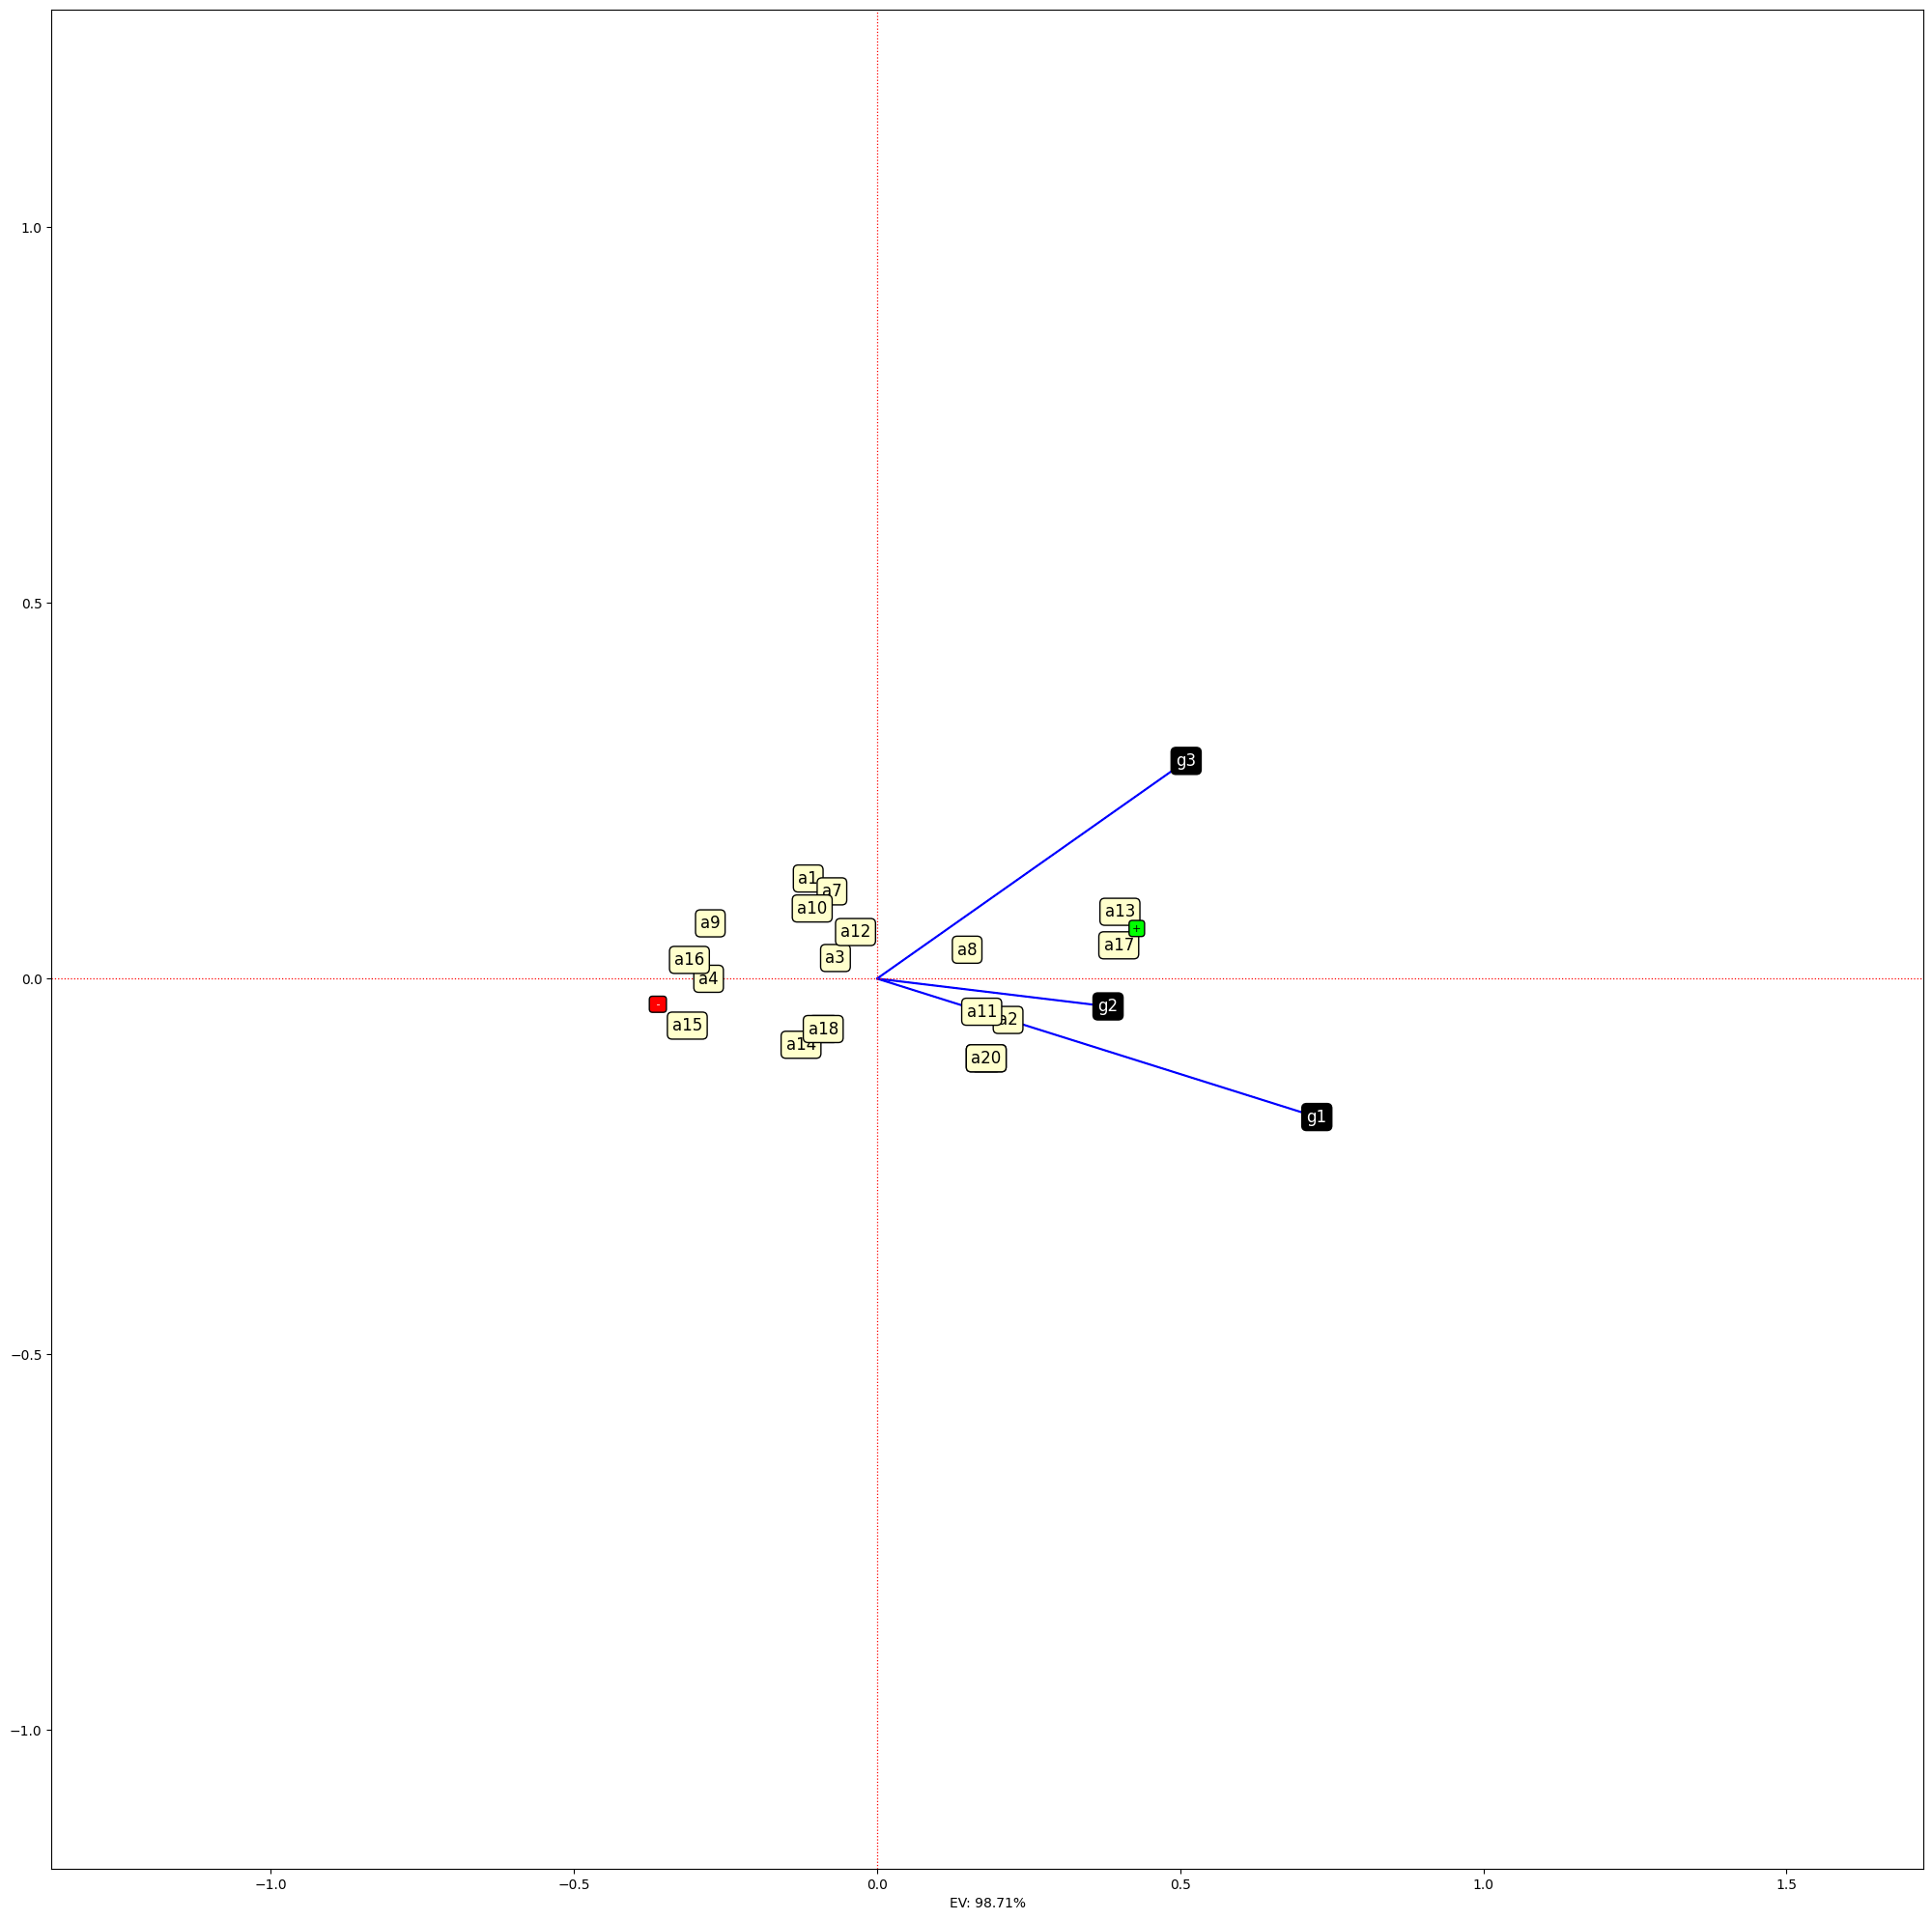

PROMETHEE I Results: {'alternatives': ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20'], 'flows': [['-', '-', '-', 'P+', '-', 'P+', '-', '-', 'P+', 'R', '-', '-', '-', 'P+', 'P+', 'P+', '-', 'P+', '-', '-'], ['P+', '-', 'P+', 'P+', 'P+', 'P+', 'P+', 'P+', 'P+', 'P+', 'P+', 'P+', '-', 'P+', 'P+', 'P+', '-', 'P+', 'P+', 'P+'], ['P+', '-', '-', 'P+', '-', 'P+', 'R', '-', 'P+', 'P+', '-', '-', '-', 'P+', 'P+', 'P+', '-', 'P+', '-', '-'], ['-', '-', '-', '-', '-', '-', '-', '-', 'R', '-', '-', '-', '-', '-', 'P+', 'P+', '-', '-', '-', '-'], ['P+', '-', 'P+', 'P+', '-', 'P+', 'P+', 'P+', 'P+', 'P+', 'R', 'P+', '-', 'P+', 'P+', 'P+', '-', 'P+', 'I', 'I'], ['-', '-', '-', 'P+', '-', '-', '-', '-', 'P+', 'R', '-', '-', '-', 'P+', 'P+', 'P+', '-', 'I', '-', '-'], ['P+', '-', 'R', 'P+', '-', 'P+', '-', '-', 'P+', 'P+', '-', '-', '-', 'P+', 'P+', 'P+', '-', 'P+', '-', '-'], ['P+', '-', 'P+', 'P+', '-', 'P+', 'P+', '-

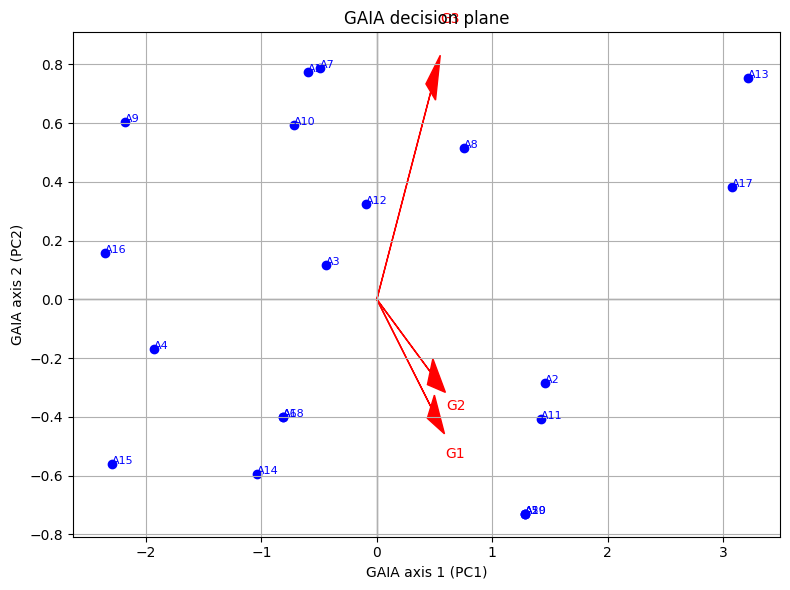

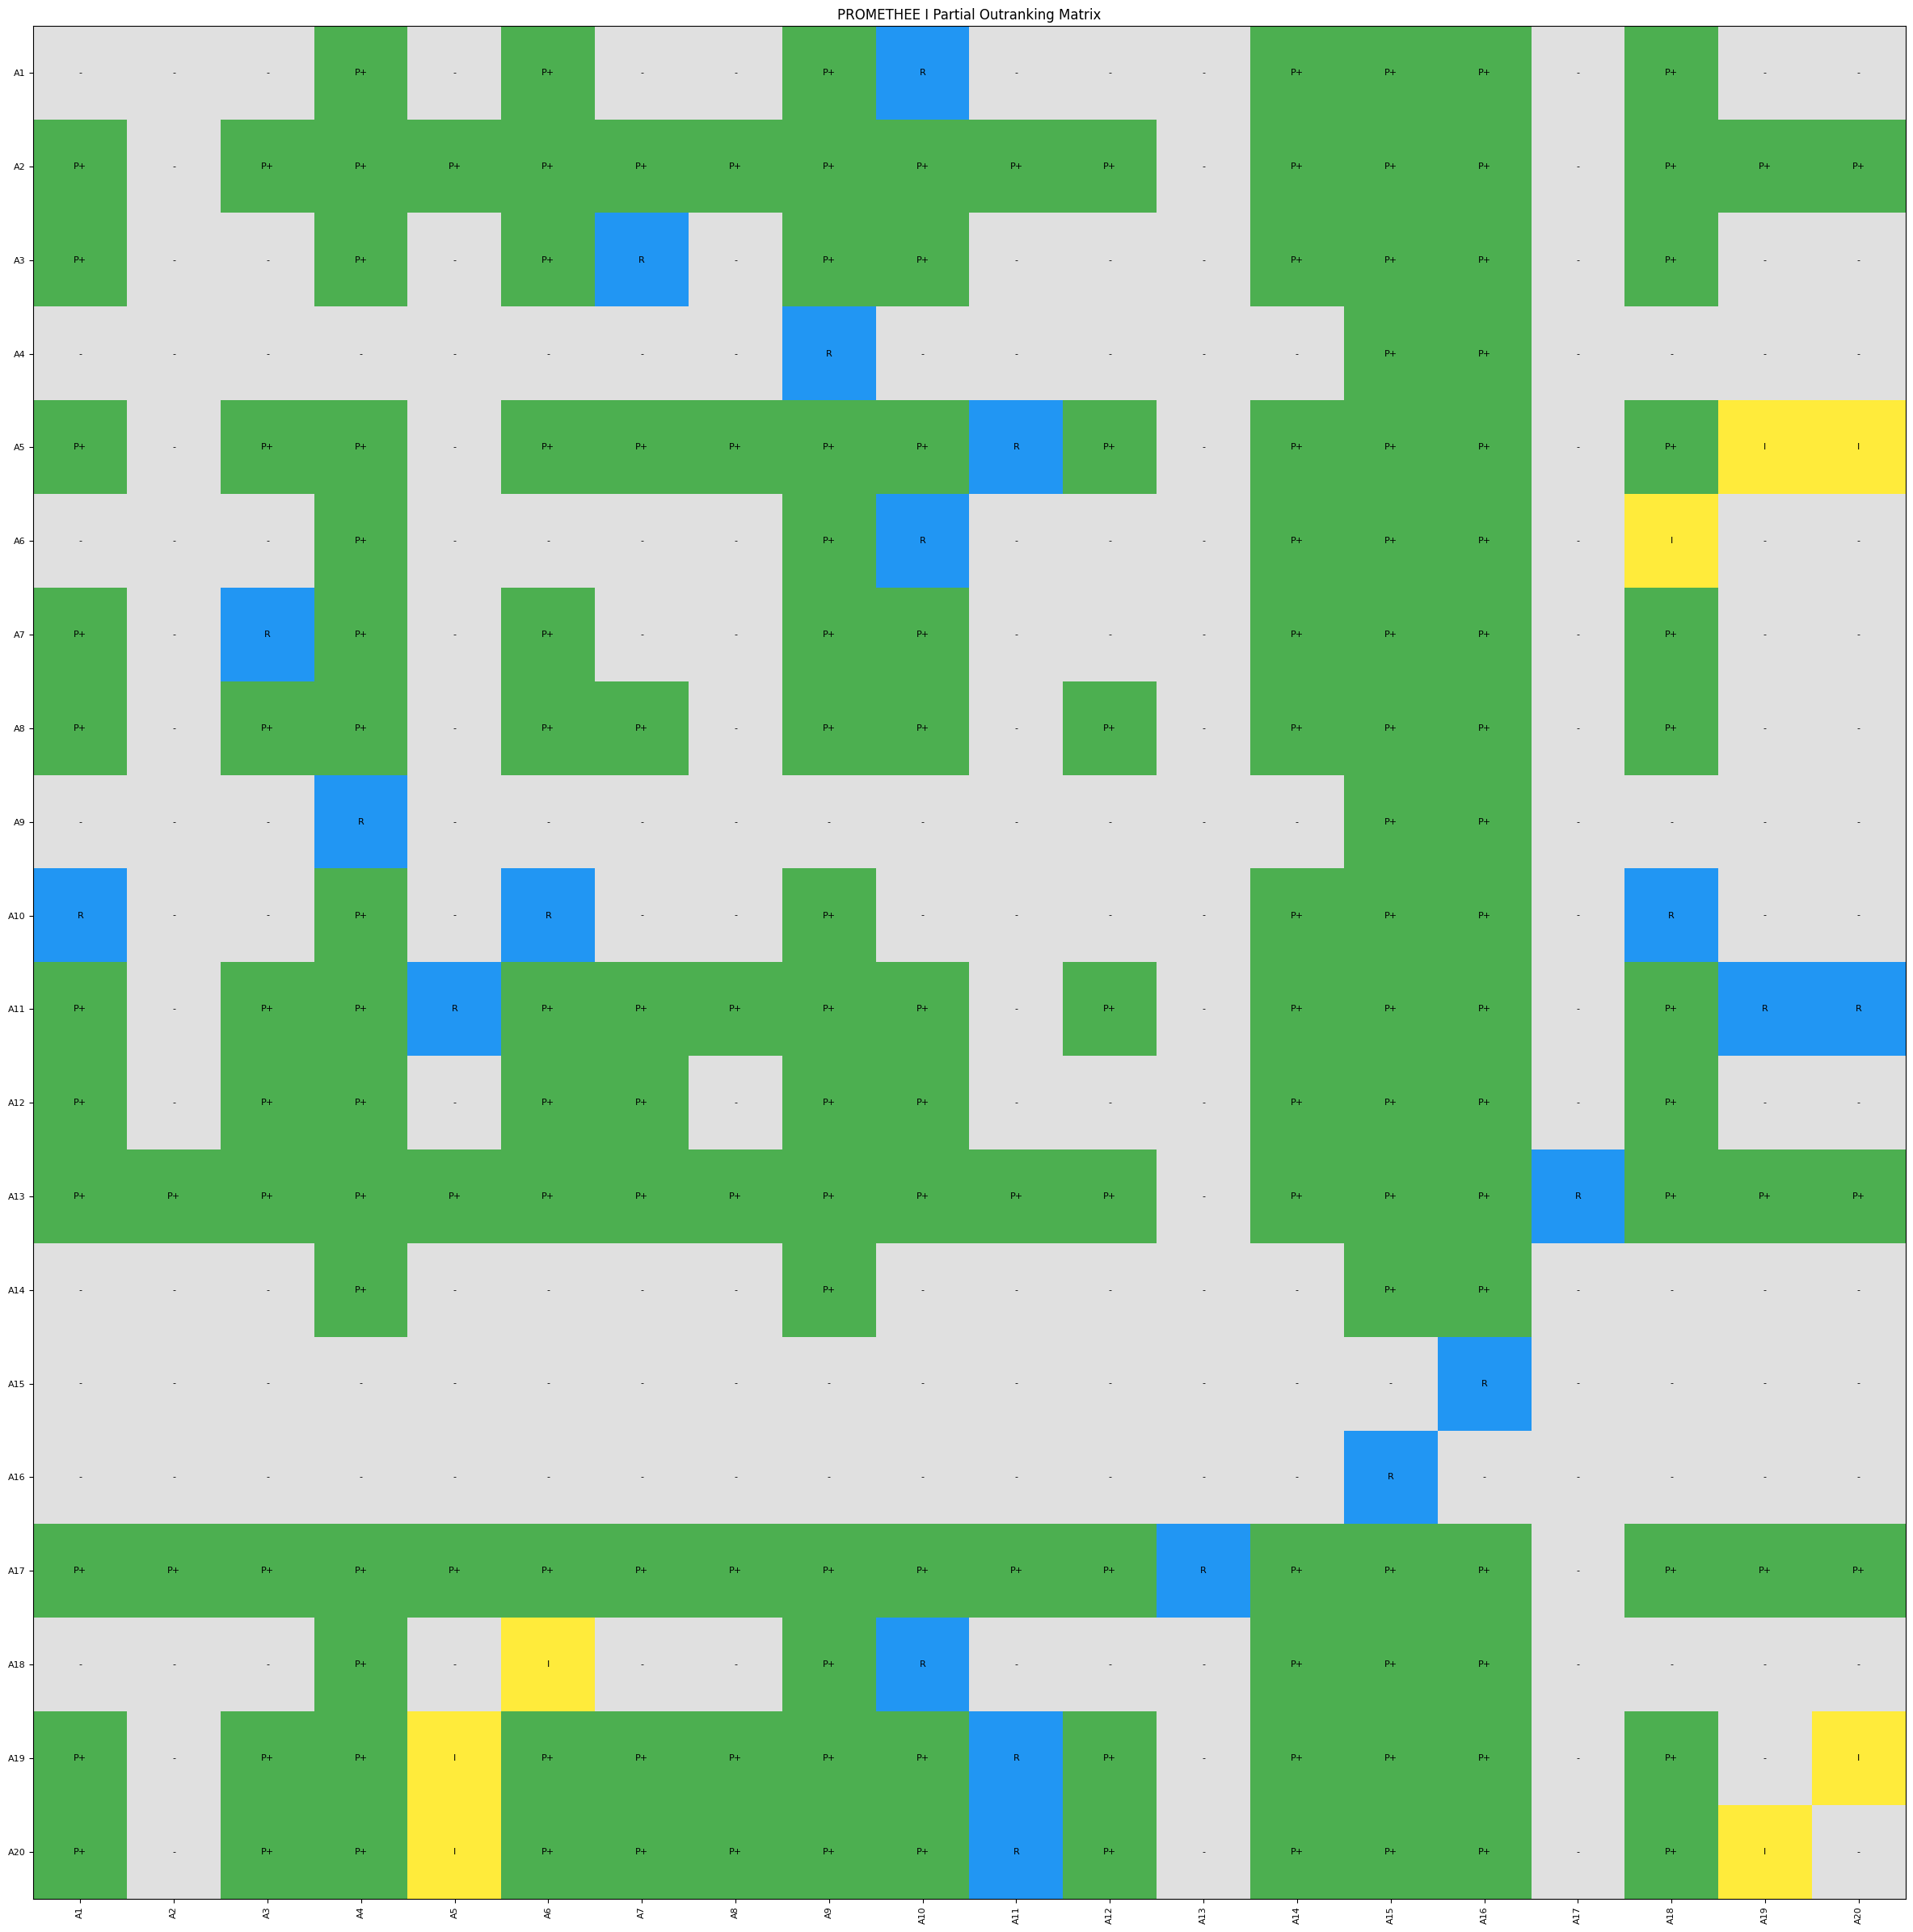

/Users/rebecamurillo/Documents/INRIA/development/ODP/sum-impact-assessment-models/src/sum_impact_assessment/models/mcda_analysis/promethee_gaia_analysis.py:128: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_alts, rotation=90, fontsize=8)


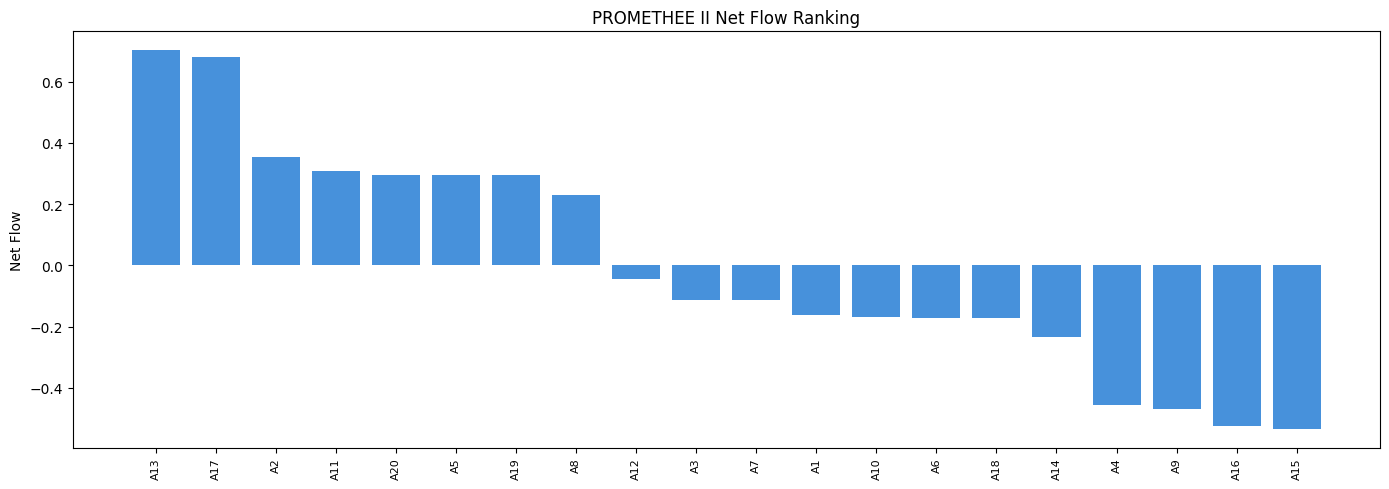

In [1]:
from src.sum_impact_assessment.utils.tools import load_living_labs_from_file, load_measures_from_file, load_kpis_from_file, load_kpi_groups_from_file
from src.sum_impact_assessment.models import KPIImpactAnalyzer, PrometheeGaiaAnalyzer
from src.sum_impact_assessment.schemas.mcda import Goal, Alternative
from src.sum_impact_assessment.schemas.impact_analysis import MeasureImpactCoefficient, LivingLabImpactError, KPIGroupImpactOutput


from pandas import DataFrame, concat

measures = load_measures_from_file('data/measures.json')
kpis = load_kpis_from_file('data/kpis.json')
kpi_groups = load_kpi_groups_from_file(
    'data/kpi_groups_mcda_goals.json', kpi_definitions=kpis)
living_labs = load_living_labs_from_file(
    'data/living_labs_data.json', kpi_definitions=kpis)


print("KPIs", "-" * 40)
print("Number of kpis : ", len(kpis))
print("Number of kpis groups: ", len(kpi_groups))

print("Number of living labs : ", len(living_labs))
for lab in living_labs:
    print(f"ID: {lab.id}")
    print(f"Name: {lab.name}")
    print(f"Number of KPIs: {len(lab.kpis)}")
    print(f"Number of Measures: {len(lab.measures)}")
    print("-" * 40)

analyzer = KPIImpactAnalyzer(living_labs, measures, kpis, kpi_groups)

final_df = DataFrame()
rreg_results: list[KPIGroupImpactOutput] = []
for group in kpi_groups:
    try:
        print(f"RUNNING ANALYSIS FOR KPI GROUP: {group.name} (ID: {group.id})")
        group_results = analyzer.run_analysis_group(group)
        rreg_results.append(group_results)
        df = DataFrame([coef.model_dump()
                       for coef in group_results.measure_coefficients])

        # add df to final_df
        final_df = concat([final_df, df], ignore_index=True)
    except Exception as e:
        print(
            f"ANALYSIS FAILED FOR KPI GROUP: {group.name} (ID: {group.id}) : {e}")
        continue

print("SAVING RESULTS TO FILES")
file_dir = 'data/output'
print(final_df)
final_df.to_csv(f"{file_dir}/final_measure_coefficients.csv", index=False)

# PROMETHEE GAIA VISUALIZATION
goals = [
    Goal(name=rreg_results[0].name, weight=0.33,
         direction="max", Q=0.0005, S=0.003, P=0.01, F='t5'),
    Goal(name=rreg_results[1].name, weight=0.33,
         direction="max", Q=0.0005, S=0.003, P=0.01, F='t5'),
    Goal(name=rreg_results[2].name, weight=0.34,
         direction="max", Q=0.0005, S=0.003, P=0.01, F='t5')
]
business_alternatives = []

for measure in measures:
    alt = Alternative(
        name=measure.name or f"Measure {measure.id}",
        values={
            rreg_alt.name: next(
                (
                    mcoef.coefficient
                    for mcoef in rreg_alt.measure_coefficients
                    if mcoef.id == measure.id
                ),
                0.0,
            )
            for rreg_alt in rreg_results
        },
    )
    business_alternatives.append(alt)

print("PROMETHEE GAIA INPUT DATA - SAVING TO CSV FILES")
print('goals', goals)
print('alternatives', business_alternatives)
# write goals and alternatives to files CSV for debugging
goals_df = DataFrame([goal.model_dump() for goal in goals])
goals_df.to_csv(f"{file_dir}/promethee_goals.csv", index=False)
# Create a matrix-style dataframe with alternatives as rows and goals as columns
alts_data = []
for alt in business_alternatives:
    row = {'name': alt.name}
    row.update(alt.values)
    alts_data.append(row)

alts_df = DataFrame(alts_data)
alts_df.to_csv(
    f"{file_dir}/promethee_goals_alternatives_matrix.csv", index=False)


print("Running PROMETHEE-GAIA analysis...")
analyzer = PrometheeGaiaAnalyzer(
    goals=goals, alternatives=business_alternatives)
result_pI = analyzer.run_prometheeI(False)
result_pII = analyzer.run_prometheeII(True)
analyzer.run_gaia(25, 25)
result_gaia = analyzer.run_gaia_custom()

print("PROMETHEE I Results:", result_pI)
print("PROMETHEE II Results:", result_pII)
print("GAIA Results:", result_gaia)

print("CUSTOM VISUALIZATIONS, SAMPLES FOR FRONT-END CLIENT")
analyzer.display_gaia()
analyzer.display_prometheeI()
analyzer.display_prometheeII()